<a href="https://colab.research.google.com/github/SandhyaSharma1512/RAG/blob/main/RAG_Implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
!pip3 install chromadb openai python-dotenv

In [32]:
import os
import json
from dotenv import load_dotenv
from openai import OpenAI
from pprint import pprint
import chromadb
from google.colab import userdata

In [33]:

# Use the Groq API key
groq_api_key = userdata.get('groq_api_key')
print(groq_api_key[:20])

# Establish a connection to Groq LLM Client


groq_client = OpenAI(
    api_key=groq_api_key,
    base_url="https://api.groq.com/openai/v1",
)

resp = groq_client.chat.completions.create(
    model="openai/gpt-oss-120b",
 messages = [
               {"role": "system", "content":"You are a helpful assistant"},
               {"role": "user", "content": "What is RAG? Explain it in 3 bullet points"}
            ])
print(resp.choices[0].message.content)


gsk_DSsssRdqOrqpNds6
- **Retrieval‑Augmented Generation (RAG)** is a hybrid AI approach that combines a large language model (the “generator”) with an external knowledge source (the “retriever”) to produce more accurate, up‑to‑date, and grounded responses.  
- **How it works:** the retriever first searches a database, vector store, or the web for the most relevant documents or passages; those retrieved texts are then fed into the generator as additional context, guiding the model’s output.  
- **Benefits:** RAG reduces hallucinations, improves factual correctness, allows the system to incorporate domain‑specific or real‑time information without retraining the entire model, and can be customized by swapping out the retrieval index or the underlying LLM.


In [34]:
with open('/content/company_hr_policy.txt','r') as f:
  var = f.read()
with open('/content/company_hr_policy.txt', 'r') as f:
    hr_document = f.read()
with open('/content/engineering_standards.txt', 'r') as f:
    eng_document = f.read()
with open('/content/onboarding_guide.txt', 'r') as f:
    onb_document = f.read()
with open('/content/product_knowledge_base.txt', 'r') as f:
    prod_document = f.read()
with open('/content/security_policy.txt', 'r') as f:
    sec_document = f.read()

In [35]:
print(f"HR Document Length: {len(hr_document)}")
print(f"my name is sndhya:{len(hr_document)}")
print(f"Engineering Document Length: {len(eng_document)}")
print(f"Onboarding Document Length: {len(onb_document)}")
print(f"Product Document Length: {len(prod_document)}")
print(f"Security Document Length: {len(sec_document)}")
print('=' * 100)
print('#' * 100)
print(f"HR Policy Token Count: {len(hr_document.split())}")
print(f"Engineering Standards Token Count: {len(eng_document.split())}")
print(f"Onboarding Document Token Count: {len(onb_document.split())}")
print(f"Product Knowledge Document Token Count: {len(prod_document.split())}")
print(f"Security Document Token Count: {len(sec_document.split())}")

HR Document Length: 3567
my name is sndhya:3567
Engineering Document Length: 4272
Onboarding Document Length: 3457
Product Document Length: 3674
Security Document Length: 4592
####################################################################################################
HR Policy Token Count: 545
Engineering Standards Token Count: 608
Onboarding Document Token Count: 523
Product Knowledge Document Token Count: 536
Security Document Token Count: 637


In [36]:
def chunk_document(text, source):
    paragraphs = text.split('\n\n')
    chunks = []
    for para in paragraphs:
      para = para.strip()
      if len(para) < 50 or para.startswith('=='):
        continue
      chunks.append({'text': para, 'source': source})
    return chunks

hr_chunks = chunk_document(hr_document, 'HR Policy')
eng_chunks = chunk_document(eng_document, 'Engineering Policy')
onb_chunks = chunk_document(onb_document, 'Onboarding Policy')
prod_chunks = chunk_document(prod_document, 'Product Policy')
sec_chunks = chunk_document(sec_document, 'Security Policy')

print(f"Number of chunks in HR Policy: {len(hr_chunks)}")
print(f"Number of chunks in Engineering Policy: {len(eng_chunks)}")
print(f"Number of chunks in Onboarding Policy: {len(onb_chunks)}")
print(f"Number of chunks in Product Policy: {len(prod_chunks)}")
print(f"Number of chunks in Security Policy: {len(sec_chunks)}")
all_chunks = hr_chunks + eng_chunks + onb_chunks + prod_chunks + sec_chunks
print(f"Total number of chunks in my knowledge base: {len(all_chunks)}")

Number of chunks in HR Policy: 14
Number of chunks in Engineering Policy: 14
Number of chunks in Onboarding Policy: 11
Number of chunks in Product Policy: 13
Number of chunks in Security Policy: 13
Total number of chunks in my knowledge base: 65


In [37]:
from sentence_transformers import SentenceTransformer

sentences = [
    "this is an example sentence",
    "each sentence is converted"
]

# Correct model name
model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

# Encode sentences into embeddings
embeddings = model.encode(sentences)

# print(embeddings.shape)   # (2, 384) → 2 sentences, 384-dimensional embeddings
print(len(embeddings[0])) # show first 10 values of first embedding

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

384


In [41]:
import openai

from sentence_transformers import SentenceTransformer

# Load a pre-trained model
model = SentenceTransformer('all-MiniLM-L6-v2')

def get_sentence_transformer_embeddings(texts):
  return model.encode(texts)

# Example usage
texts = ["What is AI?", "Machine learning is a subset of AI."]
embeddings = get_sentence_transformer_embeddings(texts)
print(len(embeddings))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

2


In [42]:
documents =[]
ids = []
metadatas = []
for i,chunk in enumerate(all_chunks):
  documents.append(chunk['text'])
  ids.append(f"chunk_{i}")
  metadatas.append({"source": chunk['source']})
print(documents[10])
print(ids[10])
print(metadatas[10])

5. COMPENSATION AND BENEFITS
All employees receive:
- Group health insurance covering self, spouse, and up to 2 dependent children.
- Annual health check-up reimbursement up to INR 8,000.
- Meal allowance of INR 2,500 per month via a prepaid card.
- Internet and home-office reimbursement of INR 1,500 per month for remote-eligible roles.
- Learning and Development stipend of INR 25,000 per year for courses, certifications, or conference attendance.
chunk_10
{'source': 'HR Policy'}


In [44]:
chroma_client = chromadb.Client()
collection = chroma_client.create_collection(name="my_collection")
collection.add(
    documents=documents,
    ids=ids,
    metadatas=metadatas
)

In [45]:
collection.add(
    documents=documents,
    ids=ids,
    metadatas=metadatas
)

In [46]:
print(f"documents stored in vector db:{len(documents)}")
print(f"collection size:{collection.count()}")
print(collection.peek())

documents stored in vector db:65
collection size:65
{'ids': ['chunk_0', 'chunk_1', 'chunk_2', 'chunk_3', 'chunk_4', 'chunk_5', 'chunk_6', 'chunk_7', 'chunk_8', 'chunk_9'], 'embeddings': array([[-0.1196135 ,  0.00717911,  0.00874049, ..., -0.03861698,
        -0.02936638, -0.01799238],
       [-0.06763722,  0.00636981,  0.0122729 , ..., -0.02226918,
        -0.08578822, -0.06659909],
       [ 0.04116061, -0.04662285,  0.06901844, ...,  0.01768263,
        -0.11868811, -0.0152602 ],
       ...,
       [-0.04579735,  0.02783488, -0.01419822, ..., -0.03952927,
        -0.09133068,  0.0075918 ],
       [-0.00399136, -0.04979863, -0.02814955, ..., -0.01224839,
         0.0488844 ,  0.06995037],
       [-0.08802755,  0.04656687, -0.02724471, ..., -0.08218645,
         0.00896309,  0.03760624]]), 'documents': ['AJEYA AI ACADEMY — HUMAN RESOURCES POLICY\nDocument Version: 2.3\nLast Updated: January 2026\nOwner: People Operations Team', '1. WORKING HOURS AND ATTENDANCE\nStandard working hours at

In [47]:
### cosine similarity
from sentence_transformers import SentenceTransformer
sentence1 = "I love going out, trekking, biking"
santence2 = "I love drawing, painting"
sentence3 = "I have politics news"

model = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')
embedding1 = model.encode(sentence1)
embedding2 = model.encode(santence2)
embedding3 = model.encode(sentence3)
print(len(embedding1))




Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

384


In [48]:
import numpy as np
from  sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# stack embeddings
embeddings = np.vstack([embedding1, embedding2, embedding3])
similarity = cosine_similarity(embeddings)
print(similarity)


[[1.0000001  0.396572   0.0742796 ]
 [0.396572   1.         0.10066614]
 [0.0742796  0.10066614 0.9999998 ]]


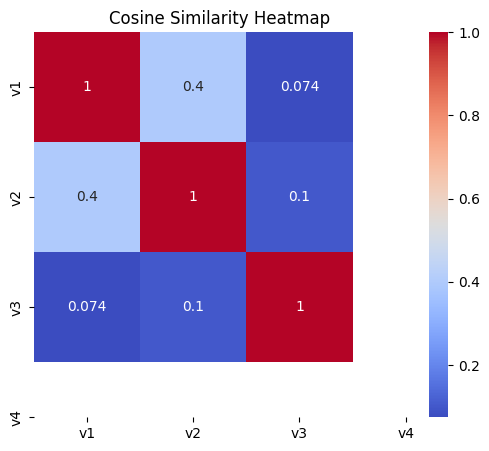

In [49]:
plt.figure(figsize=(6, 5))
sns.heatmap(similarity, annot=True, cmap="coolwarm", xticklabels=["v1","v2","v3","v4"], yticklabels=["v1","v2","v3","v4"])
plt.title("Cosine Similarity Heatmap")
plt.show()

In [50]:
def retrieve(query, n_docs=3):
  result = collection.query(
            query_texts=[query],
            n_results= n_docs
  )
  print(f"result: {result}")
  return result['documents'][0] , result['metadatas'][0]


In [51]:
document, metadata = retrieve("what is maternity leave policy", 3)
print(document[2])
print("="*60)
print(metadata)

result: {'ids': [['chunk_4', 'chunk_3', 'chunk_13']], 'embeddings': None, 'documents': [["- Sick Leave: 10 days annually, no carry-forward.\n- Casual Leave: 8 days annually, can be availed with 24 hours' notice.\n- Maternity Leave: 26 weeks as per statutory guidelines.\n- Paternity Leave: 15 days, to be availed within 6 months of childbirth.\n- Bereavement Leave: 5 days for immediate family.", '2. LEAVE POLICY\nEmployees accrue 1.5 days of paid leave per month, totaling 18 days annually. Unused leave can be carried forward up to a maximum of 30 days; anything beyond this cap is forfeited at year-end.', 'For questions regarding this policy, contact hr-policy@ajeyaaiacademy.com.']], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[{'source': 'HR Policy'}, {'source': 'HR Policy'}, {'source': 'HR Policy'}]], 'distances': [[1.0646684169769287, 1.1368467807769775, 1.2256544828414917]]}
For questions regarding this policy, contact hr-policy@ajeya

In [80]:
#create rag pipeline
def ask_rag(question, n_results=3, verbose=True):
  chunks, sources = retrieve(question, n_results)
  if verbose:
    print("\n{'='*60}")
    print(f"question:{question}")
    print("\n{'='*60}")
    print(f"source:{sources}")
    print(f"chunks len\n{len(chunks)}")

  for i, (chunk, source) in enumerate(zip(chunks, sources)):
    print(f"source of {source}")
    print(chunk)
  context = "\n\n".join(chunks)
  messages = [
        {
            "role": "system",
            "content": (
                '''
                    You are a helpful company assistant. Answer questions using only the provided context.
                    If the context does not contain the answer, say I dont know or i dont have enough information to answer this
                    Be concise
                '''
            )
        },
        {
            "role": "user",
            "content": f"Context:\n{context}\n\n Question: {question}"
        }
    ]
  resp = groq_client.chat.completions.create(
          model="openai/gpt-oss-120b",
          messages= messages)
  print(resp)
#  return resp.choices[0].message.content
# print(resp.choices[0].message.content)

In [79]:
ask_rag("how can update the document")

result: {'ids': [['chunk_20', 'chunk_39', 'chunk_49']], 'embeddings': None, 'documents': [['Pull requests larger than 400 lines of changes (excluding auto-generated files) should be split into smaller, logically separable PRs wherever possible.', 'AJEYA AI ACADEMY — PRODUCT KNOWLEDGE BASE\nDocument Version: 3.0\nLast Updated: April 2026\nOwner: Product Team', 'CUSTOMER SUPPORT\nLearner support is available via in-app chat (9 AM - 9 PM IST, all days) and email at support@ajeyaaiacademy.com, with a target first-response time of 4 hours during support hours. Technical issues (video playback, login) are escalated to the Platform Engineering team with a 24-hour resolution SLA.']], 'uris': None, 'included': ['metadatas', 'documents', 'distances'], 'data': None, 'metadatas': [[{'source': 'Engineering Policy'}, {'source': 'Product Policy'}, {'source': 'Product Policy'}]], 'distances': [[1.6667900085449219, 1.68574059009552, 1.6964693069458008]]}

{'='*60}
question:how can update the document



'I don’t have enough information to answer that.'